<a href="https://www.kaggle.com/code/cartelsmith/spider-web-charts-dbscan-clustering?scriptVersionId=336582473" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [9]:

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "penguins.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "youssefaboelwafa/clustering-penguins-species",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_theme(context='notebook', style='darkgrid')
import pandas as pd


# General Dataset Info

In [10]:
display(df.head())
print(30*"--")
print(df.info())

df['sex'] = df['sex'].astype('category') # Converting the 'Sex' column to category datatype

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB
None


# Preprocessing Data

In [11]:
display(df.describe().T) # checking the spread of the data
print('***'*30)
print(f"Because the spread of feature data is orders of magnitude different, I'll have to scale them.")
print('***'*30)

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.50,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.70,21.5
flipper_length_mm,342.0,214.014620,260.558057,-132.0,190.000,197.00,213.75,5000.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.00,6300.0


******************************************************************************************
Because the spread of feature data is orders of magnitude different, I'll have to scale them.
******************************************************************************************


# Data Analysis (EDA)

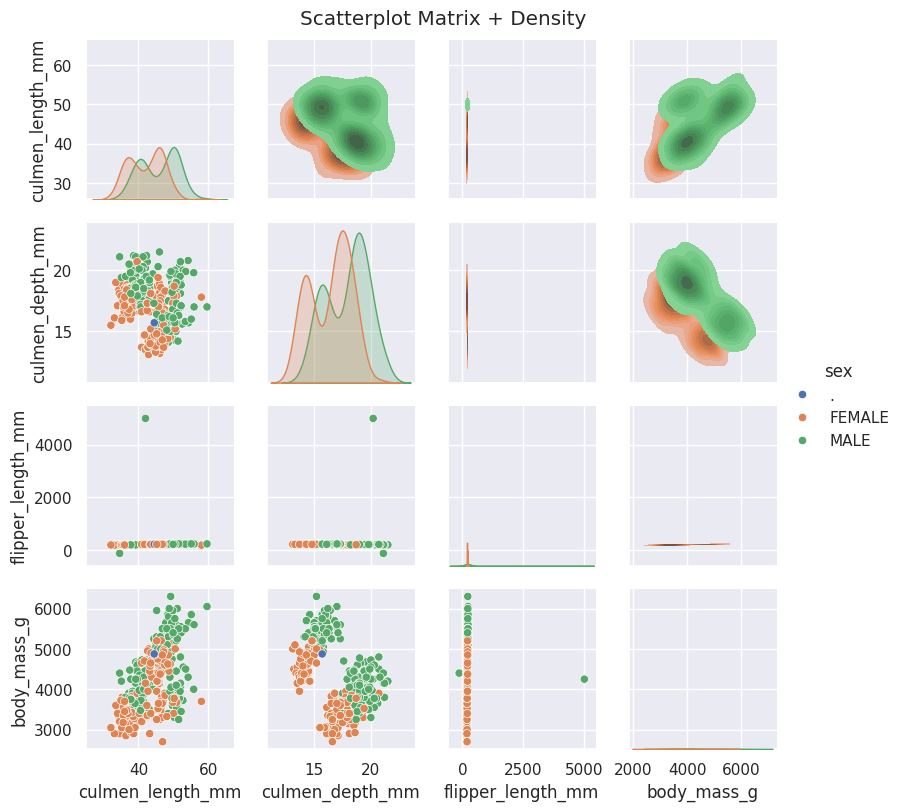

------------------------------------------------------------

             Understanding missing values

------------------------------------------------------------


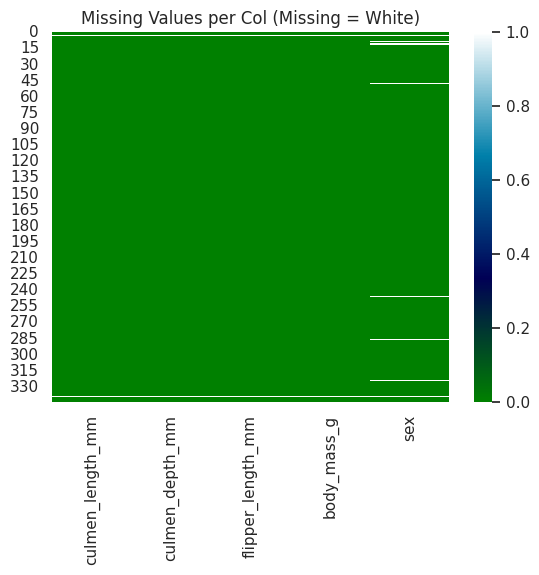

------------------------------------------------------------
Missing Values per Col:
culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64


In [12]:
# Plotting the data
grid = sns.PairGrid(df, hue='sex', height=2, aspect=1)
grid.map_diag(sns.kdeplot, fill=True)
grid.map_upper(sns.kdeplot, fill=True)
grid.map_lower(sns.scatterplot)

grid.add_legend()
plt.suptitle('Scatterplot Matrix + Density',y=1.01)
plt.show()


"""print(f"\n\nIt looks like the 'sex' feature has a period somewhere in column. Let's see how many rows have this issue.")
print(30*"--")
print(f"Value Counts for 'Sex' column:\n{df.sex.value_counts()}")

# Replacing the single '.' in the 'Sex' column with the mode value ('MALE')
mode = df['sex'].mode().tolist() # Finding mode
print(30*"--")
print(f'\nThe mode is: {mode}')

df.loc[df['sex'] == '.', 'sex'] = 'MALE'
df['sex'] = df['sex'].cat.remove_unused_categories()"""

# Understanding Missing Values
print('---'*20)
print('\n             Understanding missing values\n')
print('---'*20)

# 1. Heatmap
sns.heatmap(df.isna(), cmap='ocean')
plt.title("Missing Values per Col (Missing = White)")
plt.show();

# 2. Printing
print('---'*20)
print(f"Missing Values per Col:\n{df.isna().sum()}")




# Imputing Missing Values & Scaling

In [13]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_dtypes = df.select_dtypes(include='number').columns.tolist()     # Identifying numeric columns in dataset
cat_dtypes = df.select_dtypes(include='category').columns.tolist()      # Identifying catgorical columns in dataset

# Building pipelines
num_pipe = Pipeline(steps=[('scale_num', RobustScaler()),
                           ('impute_num',KNNImputer(n_neighbors=5))])

cat_pipe = Pipeline(steps=[('impute_cat', SimpleImputer(strategy='most_frequent')),
                           ('OneHot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
                           ])
# Building preprocessor
preprocessor = ColumnTransformer(transformers=[('num', num_pipe, num_dtypes),
                                               ('cat',cat_pipe,cat_dtypes)
                                              ])


# Fitting preprocessor
df_cleaned = preprocessor.fit_transform(df)
 



# Dimensionality Reduction + Data Visualization

The cleaned df shape is: (344, 7)

--------------------------------------------------


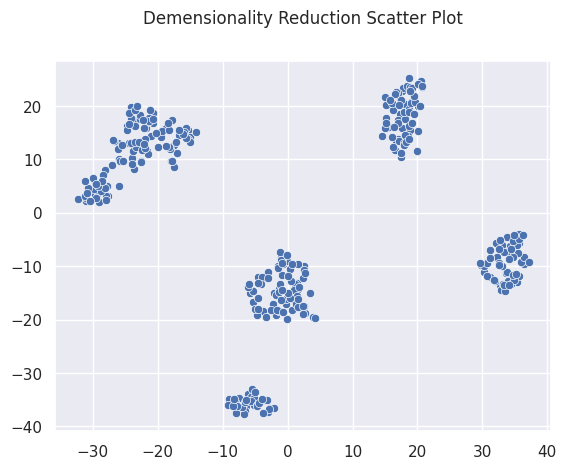

In [14]:
from sklearn.manifold import TSNE
import plotly.io as pio
import plotly.express as px

# Set the default renderer to iframe
pio.renderers.default = "iframe"


print(f'The cleaned df shape is: {df_cleaned.shape}\n')
print('--'*25)

tsne = TSNE(n_components=2,random_state=12, perplexity=20)
df_tsne = tsne.fit_transform(df_cleaned)

# Ploting TSNE output
x = df_tsne[:,0]
y = df_tsne[:,1]

sns.scatterplot(x=x,y=y)
plt.title("Demensionality Reduction Scatter Plot", y =1.08);

# 3D Scatter
tsne_3d = TSNE(n_components=3,random_state=12, perplexity=20)
df_tsne_3d = tsne_3d.fit_transform(df_cleaned)

# Ploting TSNE 3D output
x = df_tsne_3d[:,0]
y = df_tsne_3d[:,1]
z = df_tsne_3d[:,2]


fig = px.scatter_3d(df_tsne_3d, x=x, y=y, z=z,
                    width=1000, height= 1000, color_discrete_sequence=['green'])

fig.update_layout(scene_zaxis_type="log")
fig.show()


# Clustering Algorithm

In [15]:
from sklearn.cluster import DBSCAN

dbsc = DBSCAN(min_samples=10, eps=.5)

dbsc.fit(df_cleaned)
labels = dbsc.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)


Estimated number of clusters: 5
Estimated number of noise points: 17


# Evaluating Clustering

In [16]:
# Radar Charts
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Recover the column names and recreate the DataFrame
feature_names = preprocessor.get_feature_names_out()
df_clustered = pd.DataFrame(df_cleaned, columns=feature_names)
df_clustered['Cluster'] = labels

# 2. Calculate the average of each feature per cluster
cluster_means = df_clustered.groupby('Cluster').mean().reset_index()

# Drop the noise points (-1) because their average isn't a cohesive group
cluster_means = cluster_means[cluster_means['Cluster'] != -1]

# 3. Setup subplots specifically for Polar charts
n_clusters = len(cluster_means)
cols = 3
rows = (n_clusters + cols - 1) // cols  # Dynamically calculate needed rows

# CRITICAL: We must specify {'type': 'polar'} in the specs for radar charts
fig = make_subplots(
    rows=rows, 
    cols=cols, 
    specs=[[{'type': 'polar'}] * cols for _ in range(rows)],
    subplot_titles=[f"Cluster {int(c)}" for c in cluster_means['Cluster']]
)

# 4. Iterate through each cluster and draw a radar chart
for i, (_, row) in enumerate(cluster_means.iterrows()):
    r_pos = (i // cols) + 1
    c_pos = (i % cols) + 1
    
    # Isolate just the features (drop the Cluster ID label)
    features = row.drop('Cluster')
    theta_values = features.index.tolist()
    r_values = features.values.tolist()
    
    # To make the shape fully close, we append the first value to the end of the list
    theta_values.append(theta_values[0])
    r_values.append(r_values[0])
    
    # Add the radar polygon
    fig.add_trace(go.Scatterpolar(
        r=r_values,
        theta=theta_values,
        fill='toself',
        name=f"Cluster {int(row['Cluster'])}"
    ), row=r_pos, col=c_pos)

# 5. Clean up the layout
fig.update_layout(
    height=400 * rows,  # Scale total height based on number of rows
    width=1200,
    title_text="Feature Commonalities by DBSCAN Cluster",
    showlegend=False
)

fig.show()